# Magnetics-only reconstruction testing

Set the path to the EFIT file and pick a time-slice to analyse:

In [1]:
efit_path = "/home/chris/astora-mastu/dev/epm044862.nc"
time_index = 100

### Basis set-up

Here we load our stored mesh for modelling the toroidal plasma current density, and use `HexaconeBasis` to create a set of hexagonal-base pyramid basis functions, with one placed at each mesh vertex. This combination of basis functions generates a piecewise-linear representation of the plasma current density over the mesh.

In [2]:
from astora.mesh.basis import HexaconeBasis
from numpy import load

mesh = load("field_mesh.npz")
mesh_size = mesh["R"].size

hex_basis = HexaconeBasis(
    R=mesh["R"],
    z=mesh["z"],
    resolution=mesh["resolution"],
)


### PF coil set-up

In [3]:
from astora.diagnostics.magnetics.coils import CoilSet
from mastora.diagnostics.magnetics.coils import get_mastu_coils

coil_dict = get_mastu_coils()
mastu_coil_set = CoilSet(coils = [coil for coil in coil_dict.values()])

### Field probe set-up

In [4]:
from astora.diagnostics.magnetics.models import FieldSensorModel
from mastora.diagnostics.magnetics.probes import get_probe_data

probe_specs, probe_data = get_probe_data(filepath=efit_path)

field_probes_model = FieldSensorModel(
    field_sensor_specs=probe_specs,
    basis=hex_basis,
    coil_set=mastu_coil_set
)

In [5]:
from midas.likelihoods import GaussianLikelihood

probe_timeslice = probe_data.get_slice(time_index=time_index)

probe_likelihood_func = GaussianLikelihood(
    y_data=probe_timeslice.measurements,
    sigma=probe_timeslice.uncertainties,
)

In [6]:
from midas.likelihoods import DiagnosticLikelihood

probes_diagnostic = DiagnosticLikelihood(
    diagnostic_model=field_probes_model,
    likelihood=probe_likelihood_func,
    name="field_probes"
)

### Plasma current set-up

In [7]:
from astora.diagnostics.magnetics.models import PlasmaCurrentModel

plasma_current_model = PlasmaCurrentModel(
    basis=hex_basis
)

In [8]:
from mastora.diagnostics.magnetics.current import get_plasma_current_data

plasma_current_data = get_plasma_current_data(filepath=efit_path)
plasma_current_timeslice = plasma_current_data.get_slice(time_index=time_index)

plasma_current_likelihood_func = GaussianLikelihood(
    y_data=plasma_current_timeslice.measurements,
    sigma=plasma_current_timeslice.uncertainties,
)

In [9]:
plasma_current_diagnostic = DiagnosticLikelihood(
    diagnostic_model=plasma_current_model,
    likelihood=plasma_current_likelihood_func,
    name="plasma_current"
)

### Flux-loop set-up

In [10]:
from astora.diagnostics.magnetics.models import FluxloopModel
from mastora.diagnostics.magnetics.fluxloops import get_fluxloop_data

fluxloop_specs, fluxloop_data = get_fluxloop_data(filepath=efit_path)

fluxloop_model = FluxloopModel(
    fluxloop_specs=fluxloop_specs,
    basis=hex_basis,
    coil_set=mastu_coil_set
)

In [11]:
fluxloop_timeslice = fluxloop_data.get_slice(time_index=time_index)

fluxloop_likelihood_func = GaussianLikelihood(
    y_data=fluxloop_timeslice.measurements,
    sigma=fluxloop_timeslice.uncertainties,
)

In [12]:
fluxloop_diagnostic = DiagnosticLikelihood(
    diagnostic_model=fluxloop_model,
    likelihood=fluxloop_likelihood_func,
    name="fluxloops"
)

### Priors set-up

As the poloidal field coil currents are free parameters, we apply a Gaussian prior to them so they are constrained by the measured values of the coil currents:

In [13]:
from midas.parameters import ParameterVector
from midas.priors import GaussianPrior
from mastora.diagnostics.magnetics.coils import get_coil_current_data


pf_data = get_coil_current_data(filepath=efit_path).get_slice(time_index=time_index)

pf_currents_prior = GaussianPrior(
    name="pf_currents_prior",
    mean=pf_data.measurements,
    standard_deviation=pf_data.uncertainties,
    parameter_vector=ParameterVector(name="coil_currents", size=pf_data.measurements.size)
)

#### Boundary current prior
If allowed, optimisation will place small current spikes around the mesh boundary to make fine adjustments to predicted measurements, in order to better fit the data.

`ZeroCurrentBoundary` places a zero-mean Gaussian prior on only the values at the mesh boundary. This in combination with a smoothness constraint prevents these non-physical boundary currents.

In [14]:
from midas.priors import BasePrior
from midas.parameters import Parameters, Fields
from numpy import ndarray, exp, zeros


class ZeroCurrentBoundary(BasePrior):
    def __init__(self, name: str, standard_deviation: float, boundary_indices: ndarray):
        self.name = name
        self.parameters = Parameters(("ln_J", mesh_size))
        self.fields = Fields()

        self.boundary_indices = boundary_indices
        self.sigma = standard_deviation
        self.weight = 1.0 / (standard_deviation**2)

    def probability(self, ln_J: ndarray) -> float:
        boundary_J = exp(ln_J[self.boundary_indices])
        return -0.5 * self.weight * (boundary_J**2).sum()

    def gradients(self, ln_J: ndarray) -> dict[str, ndarray]:
        boundary_J = exp(ln_J[self.boundary_indices])
        grad = -self.weight * boundary_J**2
        gradients = zeros(ln_J.shape)
        gradients[self.boundary_indices] = grad
        return {"ln_J": gradients}


zcb_prior = ZeroCurrentBoundary(
    name="zero_current_boundary",
    standard_deviation=50000.0, boundary_indices=mesh["boundary_indices"]
)

To enforce smoothness of the current density, we use an 'umbrella' matrix operator (analgous to a laplacian operator for a triangular mesh), and apply a zero-mean Gaussian prior to the result of applying the operator to the log-current density values on the mesh.

In [15]:
from midas.priors import LinearGaussianPrior
from tokamesh.operators import umbrella_matrix

umbrella = umbrella_matrix(
    R=mesh["R"],
    z=mesh["z"],
    triangles=mesh["triangles"],
)

smooth_current_prior = LinearGaussianPrior(
    name="smoothness_prior",
    operator=umbrella,
    mean=0.0,
    standard_deviation=0.05,
    parameter_vector=ParameterVector(name="ln_J", size=mesh["R"].size)
)

### Build posterior

In [16]:
from midas.state import PlasmaState

PlasmaState.build_posterior(
    diagnostics=[probes_diagnostic, plasma_current_diagnostic, fluxloop_diagnostic],
    priors=[pf_currents_prior, zcb_prior, smooth_current_prior],
    field_models=[]
)

### MAP estimation

To make a sensible initial guess for the current distribution, we create a Gaussian-shaped current blob and scale its amplitude to match the total measured plasma current:

In [17]:
from numpy import log, exp

# gaussian-shaped current blob
ln_J_guess = -((mesh["R"] - 0.85) / 0.3)**2 - (mesh["z"] / 0.6)**2
# scale-up the current distribution to match the measured total plasma current
guess_current = exp(ln_J_guess).sum() * hex_basis.total_current
adjust_factor = plasma_current_timeslice.measurements.sum() / guess_current
ln_J_guess += log(adjust_factor)

For the initial guess for the PF coil currents we can use the measured currents. We can use `PlasmaState.merge_parameters` to merge the guesses into a paramter array:

In [18]:

initial_guess_dict = {
    "coil_currents": pf_data.measurements,
    "ln_J": ln_J_guess,
}

initial_guess_array = PlasmaState.merge_parameters(initial_guess_dict)

Set up bounds for the optimisation using `PlasmaState.build_bounds`:

In [19]:
bounds_dict = {
    "coil_currents": (-1e5, 1e5),
    "ln_J": (-1.0, log(1.5e6)),
}

bounds = PlasmaState.build_bounds(bounds_dict)

Import the `posterior` module and verify the initial guess returns a valid log-probability:

In [20]:
from midas import posterior
print(f"initial guess log-prob {posterior.log_probability(initial_guess_array):.2f}")

initial guess log-prob 648.61


In [21]:
from scipy.optimize import minimize

opt_result = minimize(
    fun=posterior.cost,
    x0=initial_guess_array,
    method='L-BFGS-B',
    bounds=bounds,
    jac=posterior.cost_gradient,
)

# extract the MAP estimate parameters from the results
map_estimate_params = opt_result.x

# verify that the MAP parameters yield a higher log-probability than the initial guess
print(f"initial guess log-prob {posterior.log_probability(initial_guess_array):.2f}")
print(f" MAP estimate log-prob {posterior.log_probability(map_estimate_params):.2f}")

initial guess log-prob 648.61
 MAP estimate log-prob 754.50


### Data reproduction check using MAP estimate
We can use `posterior.get_model_predictions` to get the predictions of all the forward-models:


In [22]:
map_predictions = posterior.get_model_predictions(map_estimate_params)
{name for name in map_predictions.keys()}

{'field_probes', 'fluxloops', 'plasma_current'}

Check the agreement of the plasma current:

In [23]:
print(f"measured plasma current: {plasma_current_timeslice.measurements[0]:.2f}")
print(f"inferred plasma current: {map_predictions["plasma_current"]:.2f}")

measured plasma current: 744343.29
inferred plasma current: 750354.26


Check the agreement of the field probes:

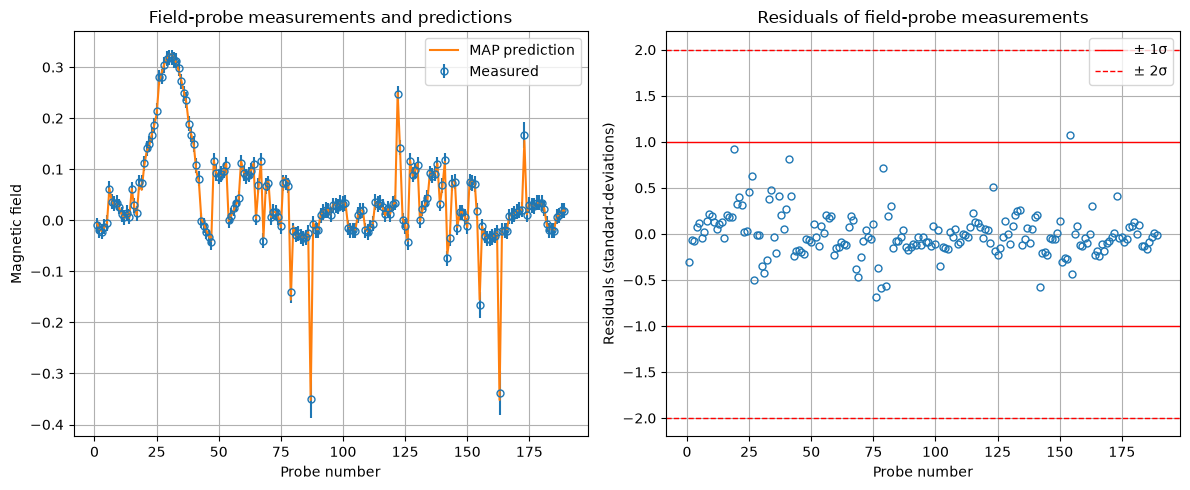

In [ ]:
import matplotlib.pyplot as plt
from numpy import arange

probe_number = arange(probe_timeslice.measurements.size) + 1
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.errorbar(
    probe_number,
    probe_timeslice.measurements,
    yerr=probe_timeslice.uncertainties,
    marker="o",
    ls="none",
    markerfacecolor="none",
    markersize=5,
    label="Measured",
)
ax1.plot(
    probe_number,
    map_predictions["field_probes"],
    label="MAP prediction",
)
ax1.set_xlabel("Probe number")
ax1.set_ylabel("Magnetic field")
ax1.set_title("Field-probe measurements and predictions")
ax1.grid()
ax1.legend()

residuals = (probe_timeslice.measurements - map_predictions["field_probes"]) / probe_timeslice.uncertainties
ax2.plot(
    probe_number,
    residuals,
    marker="o",
    ls="none",
    markerfacecolor="none",
    markersize=5,
)
ax2.axhline(1, lw=1, ls="-", c="red", label=r"$\pm$ 1$\sigma$")
ax2.axhline(-1, lw=1, ls="-", c="red")
ax2.axhline(2, lw=1, ls="--", c="red", label=r"$\pm$ 2$\sigma$")
ax2.axhline(-2, lw=1, ls="--", c="red")
ax2.set_xlabel("Probe number")
ax2.set_ylabel("Residuals (standard-deviations)")
ax2.set_title("Residuals of field-probe measurements")
ax2.grid()
ax2.legend()

fig.tight_layout()
plt.show()

Check the agreement of the flux-loops

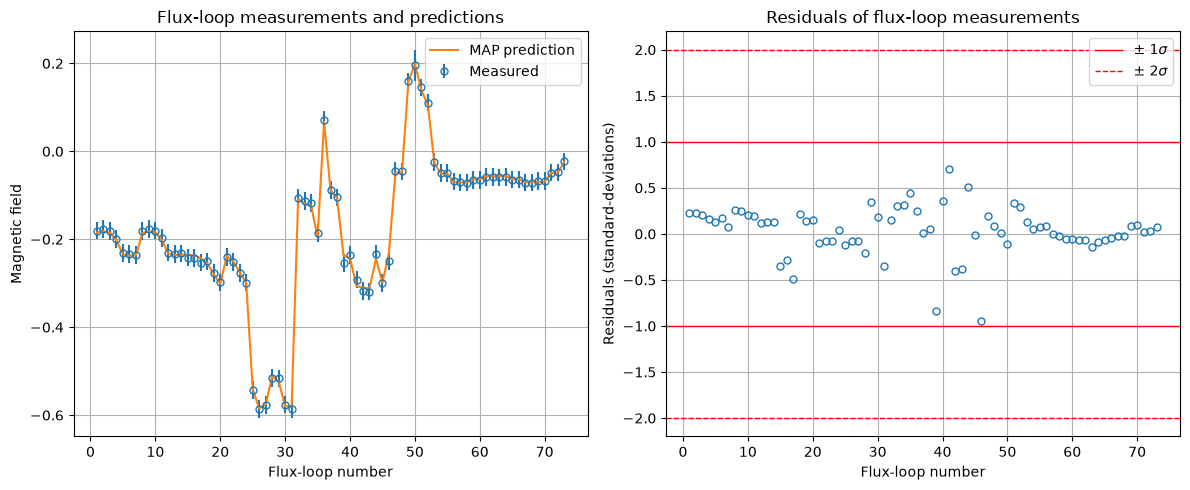

In [25]:
import matplotlib.pyplot as plt
from numpy import arange

probe_number = arange(fluxloop_timeslice.measurements.size) + 1
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.errorbar(
    probe_number,
    fluxloop_timeslice.measurements,
    yerr=fluxloop_timeslice.uncertainties,
    marker="o",
    ls="none",
    markerfacecolor="none",
    markersize=5,
    label="Measured",
)
ax1.plot(
    probe_number,
    map_predictions["fluxloops"],
    label="MAP prediction",
)
ax1.set_xlabel("Flux-loop number")
ax1.set_ylabel("Magnetic field")
ax1.set_title("Flux-loop measurements and predictions")
ax1.grid()
ax1.legend()

residuals = (fluxloop_timeslice.measurements - map_predictions["fluxloops"]) / fluxloop_timeslice.uncertainties
ax2.plot(
    probe_number,
    residuals,
    marker="o",
    ls="none",
    markerfacecolor="none",
    markersize=5,
)
ax2.axhline(1, lw=1, ls="-", c="red", label=r"$\pm$ 1$\sigma$")
ax2.axhline(-1, lw=1, ls="-", c="red")
ax2.axhline(2, lw=1, ls="--", c="red", label=r"$\pm$ 2$\sigma$")
ax2.axhline(-2, lw=1, ls="--", c="red")
ax2.set_xlabel("Flux-loop number")
ax2.set_ylabel("Residuals (standard-deviations)")
ax2.set_title("Residuals of flux-loop measurements")
ax2.grid()
ax2.legend()

fig.tight_layout()
plt.show()

### Plot the inferred toroidal current density $J_\phi$

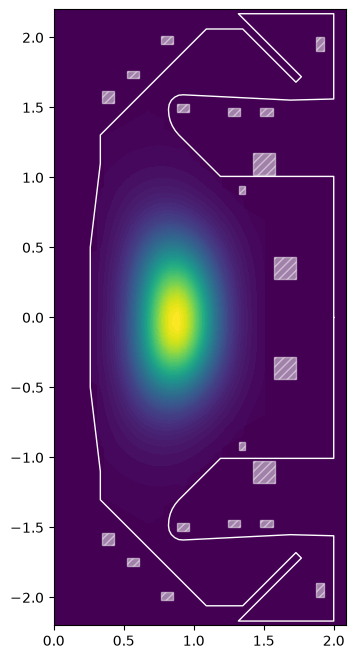

In [26]:
from tokamesh.tokamaks import mastu_boundary
from mastora.diagnostics.magnetics.coils.cases import draw_cases
from numpy import exp, inf, linspace, nextafter

map_param_dict = PlasmaState.split_parameters(map_estimate_params)
J_values = exp(map_param_dict["ln_J"])
color_levels = linspace(J_values.min(), nextafter(J_values.max(), inf), 65)

fig = plt.figure(figsize=(4.5, 8))
ax = fig.add_subplot(1, 1, 1)
ax.set_facecolor(plt.get_cmap("viridis")(0.0))
ax.tricontourf(
    mesh["R"],
    mesh["z"],
    mesh["triangles"],
    J_values,
    levels=color_levels,
    cmap="viridis",
)

ax.plot(*mastu_boundary(), lw=1, color="white")
draw_cases(ax, fill_color="white")
ax.set_aspect("equal")
ax.set_xlim([0, None])
ax.set_ylim([-2.2, 2.2])
plt.show()

### Calculate $\psi(R, z)$

Build a mesh on which to evaluate $\psi$:

In [27]:
from numpy import linspace, meshgrid
n = 64
R_axis = linspace(0.0, 2.1, n)
z_axis = linspace(-2.2, 2.2, 2*n)
R_mesh, z_mesh = meshgrid(R_axis, z_axis, indexing='ij')

Get the $\psi$ contribution from the PF coils:

In [28]:
pf_psi = mastu_coil_set.psi(currents=pf_data.measurements, R=R_mesh.flatten(), z=z_mesh.flatten())
pf_psi = pf_psi.reshape(R_mesh.shape)

Get the $\psi$ contribution from the plasma current and calcualte the total $\psi$:

In [29]:
plasma_psi_matrix = hex_basis.get_psi_matrix(R=R_mesh.flatten(), z=z_mesh.flatten())
plasma_psi = plasma_psi_matrix @ J_values
plasma_psi = plasma_psi.reshape(R_mesh.shape)

psi = pf_psi + plasma_psi

Use the `NormalisedPoloidalFlux` tool from `astora` to get $\psi_N$:

In [30]:
from astora.tools import NormalisedPoloidalFlux
psi = pf_psi + plasma_psi
PsiNorm = NormalisedPoloidalFlux(R=R_axis, z=z_axis, psi=psi, boundary=None)

Plot $\psi_N$ and the separatrix:

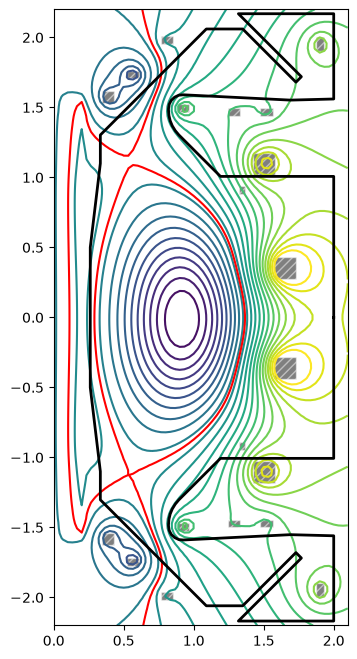

In [31]:
fig = plt.figure(figsize=(4.5, 8.0))
ax = fig.add_subplot(1, 1, 1)

PsiNorm.plot_equilibrium(axis=ax, flux_range=(0.0, 2.2))

ax.plot(*mastu_boundary(), lw=2, color="black")
draw_cases(ax, fill_color="black")

plt.show()